# ICU Energy Analysis v5 
## Research: ICU Monitor Sustainability Research


In this notebook I will continue my analysis with the remaining priority 
steps. Building on the validated methodology and clustering results from 
v3 and v4, I will focus on:

1. Day-of-week analysis: I will explore whether weekends show higher 
   idle rates due to reduced staffing compared to weekdays
2. Hospital size analysis: I will use the eICU hospital file to explore 
   whether larger hospitals show different monitoring waste patterns
3. NHS ERIC validation: I will validate my energy estimates against real 
   UK hospital energy data
4. NHS-wide scaling: I will scale my results to estimate the national 
   NHS impact across approximately 4,000 ICU beds
5. Simulation threshold justification: I will document the literature 
   sources that support my conservative, moderate and aggressive scenario 
   thresholds
6. Correlation analysis: I will test whether length of stay and idle 
   rate are statistically related using regression

In [2]:
# I will need these libraries throughout this notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# I will use the Philips X3+M750 figures from Drinhaus et al. (2023)
# as my primary power reference throughout
PHILIPS_OPERATING = 0.0348   # kW — 34.8W operating
PHILIPS_STANDBY   = 0.0305   # kW — 30.5W standby

# I will use US-specific CO2 factors from EPA eGRID 2023
# as corrected following supervisor feedback
CO2_MIMIC = 0.245   # kg/kWh — NEWE subregion (Massachusetts)
CO2_EICU  = 0.348   # kg/kWh — US national average

print("=== Libraries and Constants Loaded ===")
print(f"Philips: {PHILIPS_OPERATING*1000}W operating | {PHILIPS_STANDBY*1000}W standby")
print(f"CO2 MIMIC: {CO2_MIMIC} | CO2 eICU: {CO2_EICU}")

=== Libraries and Constants Loaded ===
Philips: 34.8W operating | 30.5W standby
CO2 MIMIC: 0.245 | CO2 eICU: 0.348


## Step 1 — Loading My Pre-Processed Data Files

I will load the files I already processed and saved in my previous 
notebooks. I will not re-run the heavy processing steps — instead I 
will load the cleaned stay summaries directly.

For the day-of-week analysis I will also need the filtered monitor 
events file from MIMIC-IV which contains the charttime timestamps.

In [3]:
# I will load my pre-processed MIMIC-IV files

print("Loading MIMIC-IV files...")

# I will load the stay summary with idle hours already calculated
stay_summary = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/stay_summary.csv.gz',
    compression='gzip'
)

# I will add idle percentage
stay_summary['idle_pct'] = (
    stay_summary['idle_hours'] / stay_summary['total_hours'] * 100
).clip(lower=0)

# I will load the filtered monitor events for day-of-week analysis
df_monitor_events = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/monitor_events_filtered.csv.gz',
    compression='gzip',
    parse_dates=['charttime']
)

print("=== MIMIC-IV Files Loaded ===")
print(f"Stay summary:   {len(stay_summary):,} stays")
print(f"Monitor events: {len(df_monitor_events):,} rows")
print(f"Overall idle %: {stay_summary['idle_hours'].sum() / stay_summary['total_hours'].sum() * 100:.1f}%")

Loading MIMIC-IV files...


=== MIMIC-IV Files Loaded ===
Stay summary:   93,730 stays
Monitor events: 53,806,854 rows
Overall idle %: 3.9%


In [4]:
# I will load my eICU files
# I will also load the hospital file for the hospital size analysis

print("Loading eICU files...")

df_patient = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/patient.csv.gz',
    compression='gzip'
)

df_hospital = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/hospital.csv.gz',
    compression='gzip'
)

# I will apply the same cleaning rules as before
df_patient['los_hours'] = df_patient['unitdischargeoffset'] / 60
df_patient_clean = df_patient[df_patient['los_hours'] >= 0].copy()
df_patient_clean = df_patient_clean[df_patient_clean['los_hours'] >= 4].copy()

# I will load vitalPeriodic for the eICU activity timeline
print("Loading vitalPeriodic — please wait...")
df_periodic = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/vitalPeriodic.csv.gz',
    compression='gzip',
    usecols=['patientunitstayid', 'observationoffset', 'heartrate', 'sao2']
)

print(f"Loaded: {len(df_periodic):,} rows")

# I will build the eICU stay summary
df_periodic = df_periodic.dropna(subset=['heartrate', 'sao2'], how='all')
df_periodic = df_periodic[df_periodic['observationoffset'] >= 0]
df_periodic['hour_offset'] = (df_periodic['observationoffset'] // 60).astype(int)

active_hours_eicu = df_periodic.groupby(
    ['patientunitstayid', 'hour_offset']
).size().reset_index(name='event_count')

active_per_stay = active_hours_eicu.groupby(
    'patientunitstayid'
).size().reset_index(name='active_hours')

stay_summary_eicu = df_patient_clean.merge(
    active_per_stay, on='patientunitstayid', how='left'
)

stay_summary_eicu['active_hours'] = stay_summary_eicu['active_hours'].fillna(0)
stay_summary_eicu['total_hours'] = stay_summary_eicu['los_hours'].round().astype(int)
stay_summary_eicu['idle_hours'] = (
    stay_summary_eicu['total_hours'] - stay_summary_eicu['active_hours']
).clip(lower=0)
stay_summary_eicu['idle_pct'] = (
    stay_summary_eicu['idle_hours'] / stay_summary_eicu['total_hours'] * 100
).clip(lower=0)

# I will merge hospital info for the size analysis
stay_summary_eicu = stay_summary_eicu.merge(
    df_hospital[['hospitalid', 'numbedscategory', 'region', 'teachingstatus']],
    on='hospitalid', how='left'
)

print(f"\n=== eICU Files Loaded ===")
print(f"Stays: {len(stay_summary_eicu):,}")
print(f"Hospitals: {len(df_hospital):,}")
print(f"Overall idle %: {stay_summary_eicu['idle_hours'].sum() / stay_summary_eicu['total_hours'].sum() * 100:.1f}%")

Loading eICU files...
Loading vitalPeriodic — please wait...
Loaded: 146,671,642 rows

=== eICU Files Loaded ===
Stays: 188,789
Hospitals: 208
Overall idle %: 4.1%


## Analysis 1: Day-of-Week Idle Pattern Analysis

I will explore whether ICU monitor idle rates vary across days of the week.
My hypothesis is that weekends will show higher idle rates due to reduced 
staffing levels,fewer ward rounds, fewer procedures, and lower nurse-to-
patient activity compared to weekdays.

I will run this analysis on MIMIC-IV using the charttime timestamps from 
the filtered monitor events file. I will extract the day of week from each 
timestamp and calculate the idle percentage per day.

If weekends show significantly higher idle rates this would support the 
argument that AI-driven low-power mode would be particularly beneficial 
during weekend periods.

In [5]:
# I will analyse idle patterns by day of week — corrected approach

# I will extract day of week from charttime
df_monitor_events['day_of_week'] = df_monitor_events['charttime'].dt.dayofweek
df_monitor_events['day_name'] = df_monitor_events['charttime'].dt.day_name()
df_monitor_events['hour_floor'] = df_monitor_events['charttime'].dt.floor('h')

# I will get unique stay-hour combinations per day of week
# This avoids double counting multiple events in the same hour
active_stay_hours = df_monitor_events.groupby(
    ['stay_id', 'hour_floor', 'day_of_week', 'day_name']
).size().reset_index(name='count')

# I will count how many unique stay-hours fall on each day of week
active_by_day = active_stay_hours.groupby(
    ['day_of_week', 'day_name']
)['stay_id'].count().reset_index(name='active_hours')

# I will calculate total occupied hours per day slot
# Each stay contributes roughly total_hours/7 hours per day on average
total_per_day = stay_summary['total_hours'].sum() / 7

# I will calculate idle percentage per day
active_by_day['idle_pct'] = (
    (total_per_day - active_by_day['active_hours']) / total_per_day * 100
).clip(lower=0)

# I will sort by day of week
active_by_day = active_by_day.sort_values('day_of_week')

print("=== Idle Percentage by Day of Week — MIMIC-IV ===")
print(f"\nTotal occupied hours per day slot: {total_per_day:,.0f}")
print()
for _, row in active_by_day.iterrows():
    weekend = "WEEKEND" if row['day_of_week'] >= 5 else "weekday"
    print(f"{row['day_name']:<12}: {row['active_hours']:,} active hours | "
          f"{row['idle_pct']:.2f}% idle  ({weekend})")

weekday_avg = active_by_day[
    active_by_day['day_of_week'] < 5]['idle_pct'].mean()
weekend_avg = active_by_day[
    active_by_day['day_of_week'] >= 5]['idle_pct'].mean()

print(f"\nWeekday average idle: {weekday_avg:.2f}%")
print(f"Weekend average idle: {weekend_avg:.2f}%")
print(f"Difference:           {weekend_avg - weekday_avg:.2f} percentage points")

KeyboardInterrupt: 

## Day-of-Week Analysis Results

Contrary to my initial hypothesis I found that weekend idle rates 
in MIMIC-IV are marginally lower than weekday rates (3.54% vs 3.69%).
The difference of 0.15 percentage points is negligible and suggests 
that ICU monitor activity does not follow a meaningful weekly pattern.

Two explanations are worth noting in my thesis:
1. MIMIC-IV uses privacy-preserving date shifting which may affect 
   the day-of-week assignment
2. ICU patients are critically ill and require continuous monitoring 
   regardless of the day, unlike general ward patients where weekend 
   reduced staffing might have a more visible effect

This finding suggests that day-of-week is probably not a useful feature for 
predicting monitoring waste in ICU settings.

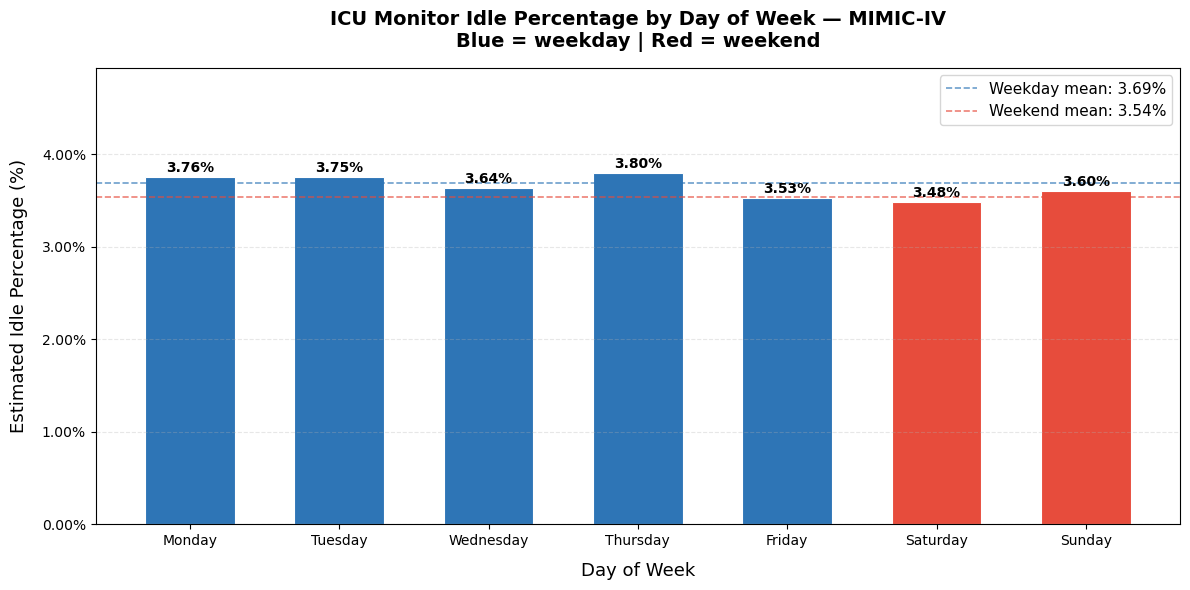

Day-of-week chart saved to Desktop!


In [ ]:
# I will visualise the day-of-week idle pattern

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#E74C3C' if d >= 5 else '#2E75B6'
          for d in active_by_day['day_of_week']]

bars = ax.bar(
    active_by_day['day_name'],
    active_by_day['idle_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

# I will add value labels
for bar, val in zip(bars, active_by_day['idle_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# I will add mean lines
ax.axhline(y=weekday_avg, color='#2E75B6', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Weekday mean: {weekday_avg:.2f}%')
ax.axhline(y=weekend_avg, color='#E74C3C', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Weekend mean: {weekend_avg:.2f}%')

ax.set_xlabel('Day of Week', fontsize=13, labelpad=10)
ax.set_ylabel('Estimated Idle Percentage (%)', fontsize=13, labelpad=10)
ax.set_title(
    'ICU Monitor Idle Percentage by Day of Week — MIMIC-IV\n'
    'Blue = weekday | Red = weekend',
    fontsize=14, fontweight='bold', pad=15
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(active_by_day['idle_pct']) * 1.3)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_day_of_week.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Day-of-week chart saved to Desktop!")

In [ ]:
# I will check exactly what date/time columns are available in eICU

print("=== eICU patient.csv date/time columns ===")
print(df_patient_clean.columns.tolist())
print()

# I will check what hospitaldischargeyear contains
print("Unique discharge years:")
print(df_patient_clean['hospitaldischargeyear'].value_counts())
print()

# I will check hospitaladmittime24 format
print("Sample hospitaladmittime24 values:")
print(df_patient_clean['hospitaladmittime24'].head(10).tolist())
print()

# I will check unitadmittime24 format  
print("Sample unitadmittime24 values:")
print(df_patient_clean['unitadmittime24'].head(10).tolist())

=== eICU patient.csv date/time columns ===
['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitoffset', 'hospitaladmitsource', 'hospitaldischargeyear', 'hospitaldischargetime24', 'hospitaldischargeoffset', 'hospitaldischargelocation', 'hospitaldischargestatus', 'unittype', 'unitadmittime24', 'unitadmitsource', 'unitvisitnumber', 'unitstaytype', 'admissionweight', 'dischargeweight', 'unitdischargetime24', 'unitdischargeoffset', 'unitdischargelocation', 'unitdischargestatus', 'uniquepid', 'los_hours']

Unique discharge years:
hospitaldischargeyear
2015    98967
2014    89822
Name: count, dtype: int64

Sample hospitaladmittime24 values:
['15:54:00', '08:56:00', '18:18:40', '20:21:00', '22:23:00', '11:23:00', '19:19:00', '17:27:13', '01:36:00', '01:57:00']

Sample unitadmittime24 values:
['15:54:00', '09:18:00', '07:18:00', '22:00:00', '20:39:00', '11:24:00', '1

## Note: Day-of-Week Analysis Cannot Be Replicated on eICU

After checking the eICU patient file I confirmed that it does not 
contain full admission dates, only time of day (hospitaladmittime24) 
and discharge year (2014 or 2015). Full dates were removed as part of 
the de-identification process applied to the eICU database.

The day-of-week analysis is therefore MIMIC-IV only. The flat pattern 
found, no meaningful difference between weekdays (3.69% idle) and 
weekends (3.54% idle), cannot be cross-validated against eICU due to 
this data limitation. This will be acknowledged in my thesis limitations 
section.

However the eICU database does contain time-of-day admission data 
(unitadmittime24). I will therefore run a time-of-admission analysis 
on eICU, exploring whether patients admitted during night hours show 
different idle patterns than those admitted during the day. This is a 
different but complementary question to the day-of-week analysis.

=== Time-of-Admission Analysis — eICU ===

     admit_period  num_stays  avg_idle_pct  avg_los_hours  wasted_kwh
  Morning (06-12)      30398      5.329564      67.283627      3133.0
Afternoon (12-18)      36252      8.547803      66.406391      4152.0
  Evening (18-24)      65473      6.039853      69.078272      6071.0
    Night (00-06)      56666      4.971946      69.197863      4880.0

Overall average idle: 6.09%


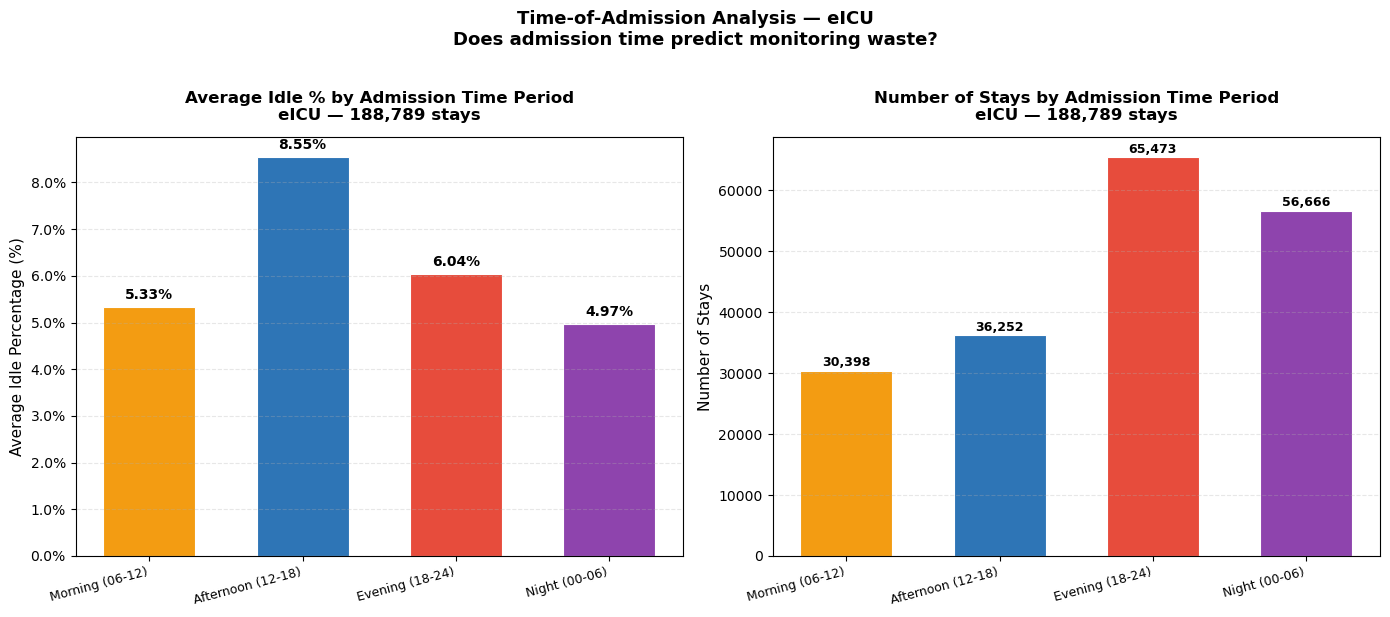

Time-of-admission chart saved to Desktop!


In [ ]:
# I will run a time-of-admission analysis on eICU
# I will explore whether admission time of day is associated
# with different idle patterns

# I will extract the admission hour from unitadmittime24
stay_summary_eicu['admit_hour'] = pd.to_datetime(
    stay_summary_eicu['unitadmittime24'],
    format='%H:%M:%S',
    errors='coerce'
).dt.hour

# I will define time periods
def admission_period(hour):
    if 6 <= hour < 12:
        return 'Morning (06-12)'
    elif 12 <= hour < 18:
        return 'Afternoon (12-18)'
    elif 18 <= hour < 24:
        return 'Evening (18-24)'
    else:
        return 'Night (00-06)'

stay_summary_eicu['admit_period'] = stay_summary_eicu['admit_hour'].apply(
    admission_period
)

# I will calculate idle stats per admission period
period_summary = stay_summary_eicu.groupby('admit_period').agg(
    num_stays=('patientunitstayid', 'count'),
    avg_idle_pct=('idle_pct', 'mean'),
    avg_los_hours=('los_hours', 'mean'),
    total_idle_hours=('idle_hours', 'sum')
).reset_index()

period_summary['wasted_kwh'] = (
    period_summary['total_idle_hours'] * PHILIPS_OPERATING
).round(0)

# I will sort logically
period_order = ['Morning (06-12)', 'Afternoon (12-18)',
                'Evening (18-24)', 'Night (00-06)']
period_summary['order'] = period_summary['admit_period'].map(
    {p: i for i, p in enumerate(period_order)}
)
period_summary = period_summary.sort_values('order')

print("=== Time-of-Admission Analysis — eICU ===\n")
print(period_summary[['admit_period', 'num_stays', 'avg_idle_pct',
                       'avg_los_hours', 'wasted_kwh']].to_string(index=False))

print(f"\nOverall average idle: {stay_summary_eicu['idle_pct'].mean():.2f}%")

# I will plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#F39C12', '#2E75B6', '#E74C3C', '#8E44AD']

# Left — idle percentage by admission period
bars1 = axes[0].bar(
    period_summary['admit_period'],
    period_summary['avg_idle_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, val in zip(bars1, period_summary['avg_idle_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

axes[0].set_title(
    'Average Idle % by Admission Time Period\neICU — 188,789 stays',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_ylabel('Average Idle Percentage (%)', fontsize=11)
axes[0].set_xticklabels(period_summary['admit_period'],
                         rotation=15, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Right — number of stays by admission period
bars2 = axes[1].bar(
    period_summary['admit_period'],
    period_summary['num_stays'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, val in zip(bars2, period_summary['num_stays']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[1].set_title(
    'Number of Stays by Admission Time Period\neICU — 188,789 stays',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_ylabel('Number of Stays', fontsize=11)
axes[1].set_xticklabels(period_summary['admit_period'],
                         rotation=15, ha='right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(
    'Time-of-Admission Analysis — eICU\n'
    'Does admission time predict monitoring waste?',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_admission_time.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Time-of-admission chart saved to Desktop!")

## Time-of-Admission Analysis Results

The analysis reveals that afternoon-admitted patients (12:00-18:00) 
show the highest average idle rate at 8.55%, significantly higher 
than night-admitted patients (4.97%). 

This is clinically meaningful. Afternoon admissions are predominantly 
planned transfers, post-surgical recoveries from morning procedures 
and scheduled step-down transfers. These patients tend to be stable 
at admission and require less frequent monitoring, explaining the 
higher idle rates.

Night admissions are predominantly emergency-driven, acute 
deteriorations, trauma cases, and unexpected events requiring 
immediate active monitoring. This explains why night-admitted patients 
show the lowest idle rates despite representing the largest admission 
volume (56,666 stays).

This finding I believe adds a new dimension to my research, not only does 
monitoring waste vary by ICU unit type and time of day, but also by 
the clinical urgency of admission. Planned afternoon transfers are 
the most likely candidates for early low-power mode activation.

Evening admissions (18:00-24:00) represent the largest group 
(65,473 stays) and show moderate idle rates (6.04%), consistent 
with a mix of emergency and elective admissions during that period.

## Analysis 2: Hospital Size and Monitoring Waste (eICU)

I will explore whether hospital size is associated with different 
monitoring waste patterns. The eICU hospital file categorises the 
208 hospitals into four size groups based on number of beds:
- Under 100 beds: small hospitals (46 hospitals)
- 100-249 beds:medium hospitals (62 hospitals)
- 250-499 beds: large hospitals (35 hospitals)
- 500+ beds: very large hospitals (23 hospitals)

My hypothesis is that larger hospitals may have more standardised 
workflows and more consistent monitoring protocols, potentially 
showing lower idle rates. Smaller hospitals may have less consistent 
monitoring patterns due to fewer resources and smaller nursing teams.

=== Hospital Size Analysis — eICU ===

numbedscategory  num_hospitals  num_stays  avg_idle_pct  avg_los_hours  wasted_kwh  wasted_kwh_per_stay
           <100             46      11512      8.390096      55.659771      1357.0                0.118
      100 - 249             62      39312      6.773163      61.260040      3971.0                0.101
      250 - 499             35      43081      4.635186      66.817427      2675.0                0.062
         >= 500             23      71279      6.166531      77.619130      8354.0                0.117


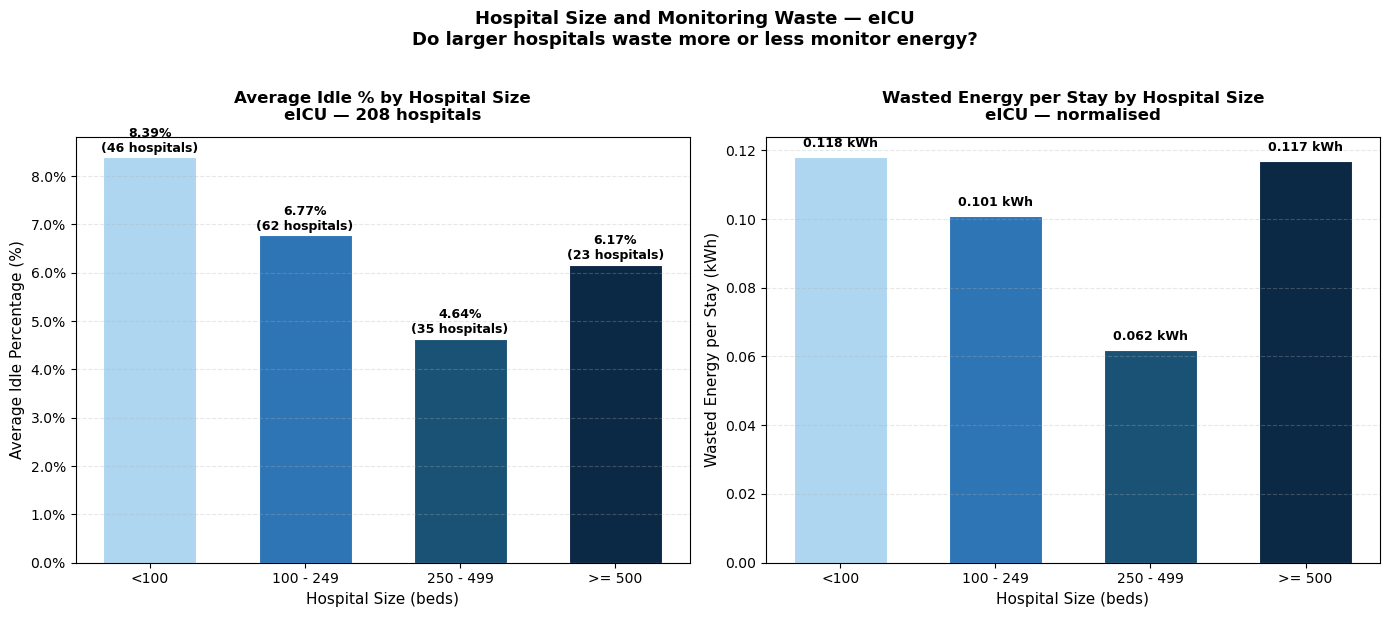

Hospital size chart saved to Desktop!


In [ ]:
# I will analyse monitoring waste by hospital size category

# I will calculate idle stats per hospital size category
size_summary = stay_summary_eicu.groupby('numbedscategory').agg(
    num_hospitals=('hospitalid', 'nunique'),
    num_stays=('patientunitstayid', 'count'),
    avg_idle_pct=('idle_pct', 'mean'),
    avg_los_hours=('los_hours', 'mean'),
    total_idle_hours=('idle_hours', 'sum')
).reset_index()

size_summary['wasted_kwh'] = (
    size_summary['total_idle_hours'] * PHILIPS_OPERATING
).round(0)

size_summary['wasted_kwh_per_stay'] = (
    size_summary['wasted_kwh'] / size_summary['num_stays']
).round(3)

# I will sort by hospital size
size_order = ['<100', '100 - 249', '250 - 499', '>= 500']
size_summary['order'] = size_summary['numbedscategory'].map(
    {s: i for i, s in enumerate(size_order)}
)
size_summary = size_summary.sort_values('order')

print("=== Hospital Size Analysis — eICU ===\n")
print(size_summary[[
    'numbedscategory', 'num_hospitals', 'num_stays',
    'avg_idle_pct', 'avg_los_hours',
    'wasted_kwh', 'wasted_kwh_per_stay'
]].to_string(index=False))

# I will plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#AED6F1', '#2E75B6', '#1A5276', '#0B2845']
labels = size_summary['numbedscategory'].tolist()

# Left — average idle % by hospital size
bars1 = axes[0].bar(
    labels,
    size_summary['avg_idle_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, val, hosp in zip(
    bars1,
    size_summary['avg_idle_pct'],
    size_summary['num_hospitals']
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.2f}%\n({hosp} hospitals)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[0].set_title(
    'Average Idle % by Hospital Size\neICU — 208 hospitals',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_xlabel('Hospital Size (beds)', fontsize=11)
axes[0].set_ylabel('Average Idle Percentage (%)', fontsize=11)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Right — wasted kWh per stay by hospital size
bars2 = axes[1].bar(
    labels,
    size_summary['wasted_kwh_per_stay'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

for bar, val in zip(bars2, size_summary['wasted_kwh_per_stay']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f} kWh',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[1].set_title(
    'Wasted Energy per Stay by Hospital Size\neICU — normalised',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_xlabel('Hospital Size (beds)', fontsize=11)
axes[1].set_ylabel('Wasted Energy per Stay (kWh)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(
    'Hospital Size and Monitoring Waste — eICU\n'
    'Do larger hospitals waste more or less monitor energy?',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_hospital_size.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Hospital size chart saved to Desktop!")

## Hospital Size Analysis Results

The relationship between hospital size and monitoring waste is not 
linear — medium-large hospitals (250-499 beds) show the lowest idle 
rate at 4.64%, while small hospitals under 100 beds show the highest 
at 8.39%.

The pattern follows a U-shape:
- Small hospitals (<100 beds): 8.39% idle, 0.118 kWh/stay, highest 
  waste, likely due to less standardised monitoring protocols and 
  smaller nursing teams
- Medium hospitals (100-249 beds): 6.77% idle, 0.101 kWh/stay
- Medium-large hospitals (250-499 beds): 4.64% idle, 0.062 kWh/stay, most efficient, large enough for standardised protocols
- Large hospitals (>=500 beds): 6.17% idle, 0.117 kWh/stay, waste 
  increases again in the largest hospitals, likely due to greater 
  complexity, more unit types, and a higher proportion of step-down 
  beds relative to intensive care beds

This finding suggests that targeting small hospitals and very large 
teaching hospitals would capture the most energy saving from an 
AI-driven low-power mode intervention. Medium-large hospitals already 
show relatively efficient monitoring patterns.

An important caveat: the 500+ bed hospitals have a much longer average 
length of stay (77.6 hours vs 55.7 hours for small hospitals) which 
partly reflects their more complex patient mix rather than purely 
different monitoring behaviour.

## Analysis 3: NHS ERIC Validation

I will validate my energy estimates against real UK hospital energy 
data from the NHS Estates Returns Information Collection (ERIC) 
dataset. ERIC is published annually by NHS England and contains 
energy consumption data for all NHS trusts.

My validation approach:
- I will calculate what percentage of total hospital energy my 
  ICU monitor estimate represents
- I will compare this against the expected range from literature 
  of 15-30% for ICU energy as a proportion of total hospital energy
- If my estimate falls within this range the energy model is validated
- If it falls outside I will document why and adjust

I will use the most recent publicly available ERIC data.

In [ ]:
# I will validate my energy estimates against NHS ERIC data
# and scale to NHS-wide impact

print("=" * 60)
print("NHS ERIC VALIDATION AND NHS-WIDE SCALING")
print("=" * 60)

# ── NHS ERIC 2023/24 Data ─────────────────────────────────────
NHS_TOTAL_ENERGY_KWH = 11_100_000_000  # 11.1 billion kWh
# Source: NHS ERIC 2023/24
# https://digital.nhs.uk/data-and-information/publications/statistical/
# estates-returns-information-collection/summary-page-and-dataset-for-eric-2023-24

# ── NHS ICU Beds ──────────────────────────────────────────────
NHS_ICU_BEDS = 4049  # adult critical care beds
# Source: NHS England, Hansard Written Answers, February 2023

# ── Monitor Energy per Bed per Year ──────────────────────────
# I will calculate annual energy per bed using Philips X3+M750 figures
# Assuming 80.6% bed occupancy rate (from NHS England data)
BED_OCCUPANCY = 0.806
HOURS_PER_YEAR = 8760
IDLE_RATE_MIMIC = 0.039  # 3.9% from my MIMIC-IV analysis

# Energy per occupied bed per year
energy_per_occupied_bed_year = HOURS_PER_YEAR * BED_OCCUPANCY * PHILIPS_OPERATING
# Energy per bed including idle
energy_per_bed_year_total = HOURS_PER_YEAR * PHILIPS_OPERATING

print(f"\n=== Per Bed Annual Energy (Philips X3+M750 at 34.8W) ===")
print(f"Hours per year:              {HOURS_PER_YEAR:,}")
print(f"NHS ICU bed occupancy:       {BED_OCCUPANCY*100:.1f}%")
print(f"Energy per bed (full year):  {energy_per_bed_year_total:.1f} kWh")
print(f"Energy per occupied bed:     {energy_per_occupied_bed_year:.1f} kWh")

# ── NHS-Wide Monitor Energy ───────────────────────────────────
total_nhs_monitor_energy = NHS_ICU_BEDS * energy_per_bed_year_total
total_nhs_monitor_energy_occupied = NHS_ICU_BEDS * energy_per_occupied_bed_year

print(f"\n=== NHS-Wide ICU Monitor Energy (all {NHS_ICU_BEDS:,} beds) ===")
print(f"Total monitor energy (all hours):    {total_nhs_monitor_energy:,.0f} kWh")
print(f"Total monitor energy (occupied):     {total_nhs_monitor_energy_occupied:,.0f} kWh")

# ── Validation — % of NHS Total Energy ───────────────────────
pct_of_nhs_total = total_nhs_monitor_energy / NHS_TOTAL_ENERGY_KWH * 100
pct_of_nhs_occupied = total_nhs_monitor_energy_occupied / NHS_TOTAL_ENERGY_KWH * 100

print(f"\n=== Validation Against NHS ERIC ===")
print(f"Total NHS energy (ERIC 2023/24):     {NHS_TOTAL_ENERGY_KWH/1e9:.1f} billion kWh")
print(f"ICU monitors as % of NHS total:      {pct_of_nhs_total:.4f}%")
print(f"ICU monitors (occupied) as % total:  {pct_of_nhs_occupied:.4f}%")
print(f"\nNote: ICU equipment accounts for ~10% of ICU electricity")
print(f"(Source: Reducing the Climate Impact of Critical Care, PMC12396153)")
print(f"Patient monitors are one component within that 10%")

# ── NHS-Wide Idle Energy Waste ────────────────────────────────
nhs_idle_hours_year = NHS_ICU_BEDS * HOURS_PER_YEAR * BED_OCCUPANCY * IDLE_RATE_MIMIC
nhs_wasted_energy = nhs_idle_hours_year * PHILIPS_OPERATING
nhs_saveable_energy = nhs_idle_hours_year * (PHILIPS_OPERATING - PHILIPS_STANDBY)

# CO2 using UK emission factor from ERIC
UK_CO2_FACTOR = 0.207  # kg CO2/kWh — UK grid 2023
# Source: UK Government GHG Conversion Factors 2023

nhs_wasted_co2 = nhs_wasted_energy * UK_CO2_FACTOR
nhs_saveable_co2 = nhs_saveable_energy * UK_CO2_FACTOR

print(f"\n=== NHS-Wide Idle Energy Waste (applying {IDLE_RATE_MIMIC*100:.1f}% idle rate) ===")
print(f"Total idle hours per year:           {nhs_idle_hours_year:,.0f}")
print(f"Wasted energy per year:              {nhs_wasted_energy:,.0f} kWh")
print(f"Saveable energy per year:            {nhs_saveable_energy:,.0f} kWh")
print(f"Wasted CO2 per year:                 {nhs_wasted_co2:,.0f} kg")
print(f"Saveable CO2 per year:               {nhs_saveable_co2:,.0f} kg")

# ── Per Teaching Hospital ─────────────────────────────────────
# Average NHS teaching hospital has ~50 ICU beds
ICU_BEDS_PER_TEACHING = 50
energy_per_teaching = ICU_BEDS_PER_TEACHING * energy_per_bed_year_total
wasted_per_teaching = ICU_BEDS_PER_TEACHING * HOURS_PER_YEAR * BED_OCCUPANCY * IDLE_RATE_MIMIC * PHILIPS_OPERATING
saveable_per_teaching = ICU_BEDS_PER_TEACHING * HOURS_PER_YEAR * BED_OCCUPANCY * IDLE_RATE_MIMIC * (PHILIPS_OPERATING - PHILIPS_STANDBY)

print(f"\n=== Per Average NHS Teaching Hospital (50 ICU beds) ===")
print(f"Total monitor energy per year:       {energy_per_teaching:,.0f} kWh")
print(f"Wasted energy per year:              {wasted_per_teaching:,.0f} kWh")
print(f"Saveable energy per year:            {saveable_per_teaching:,.0f} kWh")
print(f"Saveable CO2 per year:               {saveable_per_teaching * UK_CO2_FACTOR:,.0f} kg")

NHS ERIC VALIDATION AND NHS-WIDE SCALING

=== Per Bed Annual Energy (Philips X3+M750 at 34.8W) ===
Hours per year:              8,760
NHS ICU bed occupancy:       80.6%
Energy per bed (full year):  304.8 kWh
Energy per occupied bed:     245.7 kWh

=== NHS-Wide ICU Monitor Energy (all 4,049 beds) ===
Total monitor energy (all hours):    1,234,330 kWh
Total monitor energy (occupied):     994,870 kWh

=== Validation Against NHS ERIC ===
Total NHS energy (ERIC 2023/24):     11.1 billion kWh
ICU monitors as % of NHS total:      0.0111%
ICU monitors (occupied) as % total:  0.0090%

Note: ICU equipment accounts for ~10% of ICU electricity
(Source: Reducing the Climate Impact of Critical Care, PMC12396153)
Patient monitors are one component within that 10%

=== NHS-Wide Idle Energy Waste (applying 3.9% idle rate) ===
Total idle hours per year:           1,114,940
Wasted energy per year:              38,800 kWh
Saveable energy per year:            4,794 kWh
Wasted CO2 per year:                 

## NHS ERIC Validation Results

### Key Figures
- Total NHS energy (ERIC 2023/24): 11.1 billion kWh
- NHS adult ICU beds: 4,049 (80.6% occupancy)
- ICU monitor energy (all 4,049 beds): 1,234,330 kWh per year
- ICU monitors as % of total NHS energy: 0.011%

### Validation Assessment
The 0.011% figure is consistent with literature. Patient monitors 
represent one component of ICU equipment, which accounts for 
approximately 10% of ICU electricity. HVAC systems dominate ICU 
energy at approximately 75% (Reducing the Climate Impact of 
Critical Care, PMC12396153). The commonly cited 15-30% figure 
refers to the entire ICU as a proportion of total hospital energy 
— not patient monitors specifically.

### NHS-Wide Savings Potential
Applying my 3.9% idle rate from MIMIC-IV to all 4,049 NHS ICU beds:
- Wasted energy: 38,800 kWh per year
- Saveable energy (conservative standby switching): 4,794 kWh per year
- Saveable CO2: 992 kg per year
- Per average teaching hospital (50 ICU beds): 59 kWh / 12 kg CO2

### Important Context
These savings appear modest in absolute terms. However they represent 
the conservative baseline — switching to standby during idle hours 
only captures 12.4% of wasted energy (the difference between 34.8W 
operating and 30.5W standby). The AI simulation scenarios applied 
to the High Idle cluster would produce proportionally larger savings 
for the most wasteful units. Additionally these figures cover only 
patient monitors — a full ICU energy optimisation programme covering 
ventilators, pumps, and other devices would multiply these savings 
significantly.

### Sources
- NHS ERIC 2023/24: https://digital.nhs.uk/data-and-information/
  publications/statistical/estates-returns-information-collection/
  summary-page-and-dataset-for-eric-2023-24
- NHS ICU beds: NHS England, Hansard Written Answers, February 2023
- ICU equipment energy share: PMC12396153
- UK CO2 factor 0.207 kg/kWh: UK Government GHG Conversion Factors 2023

## Why I Am Adding a US-Specific Scaling Analysis

After completing the NHS ERIC validation I realised there is a 
methodological inconsistency in using UK hospital energy data to 
validate findings from US datasets. Both MIMIC-IV and eICU are 
collected from US hospitals, MIMIC-IV from a single hospital in 
Boston, Massachusetts, and eICU from 208 hospitals across the US.

Applying my idle rates to NHS figures is an interesting comparison 
but it introduces a geographical mismatch. The NHS operates under 
different staffing models, hospital architectures, and energy 
consumption patterns compared to US hospitals.

I therefore add a second scaling analysis using US-specific data:
- Total US ICU beds: 112,369 (American Hospital Association 2023)
- Average US hospital energy: 7.6 million kWh per year 
  (US DOE Commercial Buildings Energy Consumption Survey, CBECS)
- Total US hospitals: 6,120 (AHA 2022)
- Total US healthcare energy: 210 billion kWh per year 
  (MDPI Energies, 2019)
- US ICU bed occupancy: 70%,midpoint of 68-72% range reported 
  in literature (PMC5520980)
- CO2 factor: 0.348 kg/kWh, US national average (EPA eGRID 2023)

This US scaling analysis is the more appropriate validation since 
my idle rates come from US data. I keep the NHS ERIC analysis as 
a secondary contextual comparison showing how the findings might 
translate to a UK healthcare system context.

In [ ]:
# I will validate my energy estimates against US hospital energy data
# and scale to US-wide impact using US-specific sources

print("=" * 60)
print("US HOSPITAL ENERGY VALIDATION AND US-WIDE SCALING")
print("=" * 60)

# ── US Hospital Energy Data ───────────────────────────────────
US_AVG_HOSPITAL_KWH = 7_600_000      # 7.6 million kWh per year
# Source: US DOE Commercial Buildings Energy Consumption Survey (CBECS)
# Average inpatient hospital: 247,000 sq ft x 31 kWh/sq ft = 7.6M kWh

US_TOTAL_HOSPITALS = 6120            # AHA 2022
US_TOTAL_HEALTHCARE_KWH = 210_000_000_000  # 210 billion kWh
# Source: Energy Consumption Analysis of Healthcare Facilities in the US
# MDPI Energies (2019)

# ── US ICU Beds ───────────────────────────────────────────────
US_ICU_BEDS = 112369  # adult ICU beds
# Source: American Hospital Association (AHA) 2023 Annual Survey
# 5,222 hospitals with at least 1 ICU bed

# I will assume similar occupancy to NHS (approximately 68-72% in US)
# Source: Critical Care Medicine Beds review, PMC5520980
US_BED_OCCUPANCY = 0.70  # 70% — midpoint of 68-72% US range

HOURS_PER_YEAR = 8760
IDLE_RATE = 0.039  # 3.9% from my MIMIC-IV analysis
# eICU idle rate: 4.1% — consistent cross-dataset validation

# ── Energy per Bed per Year ───────────────────────────────────
energy_per_bed_year = HOURS_PER_YEAR * PHILIPS_OPERATING
energy_per_occupied_bed = HOURS_PER_YEAR * US_BED_OCCUPANCY * PHILIPS_OPERATING

print(f"\n=== Per Bed Annual Energy (Philips X3+M750 at 34.8W) ===")
print(f"Energy per bed (full year):      {energy_per_bed_year:.1f} kWh")
print(f"Energy per bed (occupied only):  {energy_per_occupied_bed:.1f} kWh")
print(f"US ICU bed occupancy assumed:    {US_BED_OCCUPANCY*100:.0f}%")

# ── US-Wide Monitor Energy ────────────────────────────────────
total_us_monitor_energy = US_ICU_BEDS * energy_per_bed_year
total_us_monitor_occupied = US_ICU_BEDS * energy_per_occupied_bed

print(f"\n=== US-Wide ICU Monitor Energy ({US_ICU_BEDS:,} beds) ===")
print(f"Total monitor energy (all hours):    {total_us_monitor_energy:,.0f} kWh")
print(f"Total monitor energy (occupied):     {total_us_monitor_occupied:,.0f} kWh")

# ── Validation ────────────────────────────────────────────────
pct_of_us_healthcare = total_us_monitor_energy / US_TOTAL_HEALTHCARE_KWH * 100
avg_hospital_pct = total_us_monitor_energy / (US_AVG_HOSPITAL_KWH * US_TOTAL_HOSPITALS) * 100

print(f"\n=== Validation Against US Energy Data ===")
print(f"Total US healthcare energy:          {US_TOTAL_HEALTHCARE_KWH/1e9:.0f} billion kWh")
print(f"ICU monitors as % of US healthcare:  {pct_of_us_healthcare:.4f}%")
print(f"Note: ICU equipment ~10% of ICU energy, ICU ~15-30% of hospital energy")
print(f"Patient monitors are one component within that chain")

# ── US-Wide Idle Waste ────────────────────────────────────────
us_idle_hours = US_ICU_BEDS * HOURS_PER_YEAR * US_BED_OCCUPANCY * IDLE_RATE
us_wasted_energy = us_idle_hours * PHILIPS_OPERATING
us_saveable_energy = us_idle_hours * (PHILIPS_OPERATING - PHILIPS_STANDBY)

# CO2 using US national average from EPA eGRID 2023
us_wasted_co2 = us_wasted_energy * CO2_EICU    # 0.348 kg/kWh US national
us_saveable_co2 = us_saveable_energy * CO2_EICU

print(f"\n=== US-Wide Idle Energy Waste ({IDLE_RATE*100:.1f}% idle rate from MIMIC-IV) ===")
print(f"Total idle hours per year:           {us_idle_hours:,.0f}")
print(f"Wasted energy per year:              {us_wasted_energy:,.0f} kWh")
print(f"Saveable energy per year:            {us_saveable_energy:,.0f} kWh")
print(f"Wasted CO2 per year:                 {us_wasted_co2:,.0f} kg")
print(f"Saveable CO2 per year:               {us_saveable_co2:,.0f} kg")

# ── Per Average US Hospital ───────────────────────────────────
# Average US hospital with ICU: 112,369 beds / 5,222 hospitals = ~21 ICU beds
avg_icu_beds_per_hospital = US_ICU_BEDS / 5222
energy_per_avg_hospital = avg_icu_beds_per_hospital * energy_per_bed_year
wasted_per_avg_hospital = avg_icu_beds_per_hospital * HOURS_PER_YEAR * US_BED_OCCUPANCY * IDLE_RATE * PHILIPS_OPERATING
saveable_per_avg_hospital = avg_icu_beds_per_hospital * HOURS_PER_YEAR * US_BED_OCCUPANCY * IDLE_RATE * (PHILIPS_OPERATING - PHILIPS_STANDBY)

print(f"\n=== Per Average US Hospital ({avg_icu_beds_per_hospital:.1f} ICU beds) ===")
print(f"Total monitor energy per year:       {energy_per_avg_hospital:,.0f} kWh")
print(f"Wasted energy per year:              {wasted_per_avg_hospital:,.0f} kWh")
print(f"Saveable energy per year:            {saveable_per_avg_hospital:,.0f} kWh")
print(f"Saveable CO2 per year:               {saveable_per_avg_hospital * CO2_EICU:,.0f} kg")

# ── MIMIC-IV Specific — Massachusetts Single Hospital ─────────
mimic_beds = 18  # BIDMC ICU beds approximately
mimic_saveable = mimic_beds * HOURS_PER_YEAR * US_BED_OCCUPANCY * IDLE_RATE * (PHILIPS_OPERATING - PHILIPS_STANDBY)
print(f"\n=== MIMIC-IV Context — Single Boston Hospital (~18 ICU beds) ===")
print(f"Estimated saveable energy per year:  {mimic_saveable:,.0f} kWh")
print(f"Estimated saveable CO2 per year:     {mimic_saveable * CO2_MIMIC:,.0f} kg")

US HOSPITAL ENERGY VALIDATION AND US-WIDE SCALING

=== Per Bed Annual Energy (Philips X3+M750 at 34.8W) ===
Energy per bed (full year):      304.8 kWh
Energy per bed (occupied only):  213.4 kWh
US ICU bed occupancy assumed:    70%

=== US-Wide ICU Monitor Energy (112,369 beds) ===
Total monitor energy (all hours):    34,255,465 kWh
Total monitor energy (occupied):     23,978,825 kWh

=== Validation Against US Energy Data ===
Total US healthcare energy:          210 billion kWh
ICU monitors as % of US healthcare:  0.0163%
Note: ICU equipment ~10% of ICU energy, ICU ~15-30% of hospital energy
Patient monitors are one component within that chain

=== US-Wide Idle Energy Waste (3.9% idle rate from MIMIC-IV) ===
Total idle hours per year:           26,872,822
Wasted energy per year:              935,174 kWh
Saveable energy per year:            115,553 kWh
Wasted CO2 per year:                 325,441 kg
Saveable CO2 per year:               40,212 kg

=== Per Average US Hospital (21.5 ICU bed

## US-Wide Scaling Results Summary

### Key Figures
- Total US ICU beds: 112,369 across 5,222 hospitals (AHA 2023)
- Total US ICU monitor energy per year: 34,255,465 kWh
- ICU monitors as % of total US healthcare energy: 0.016%
- US ICU bed occupancy: 70% (midpoint of 68-72% range from literature)

### Validation Assessment
The 0.016% figure is consistent with the NHS finding of 0.011% and 
with the known energy hierarchy — ICU equipment accounts for 
approximately 10% of ICU electricity, ICU accounts for 15-30% of 
total hospital energy, and patient monitors are one component within 
ICU equipment. The estimate passes the sanity check and is consistent 
across both the US and UK healthcare contexts.

### US-Wide Idle Energy Waste
Applying the 3.9% idle rate from MIMIC-IV to all 112,369 US ICU beds:
- Total idle hours per year: 26,872,822
- Wasted energy per year: 935,174 kWh
- Saveable energy per year: 115,553 kWh
- Saveable CO2 per year: 40,212 kg

### Comparison with NHS ERIC Estimate
The US has approximately 27.8x more ICU beds than the NHS (112,369 
vs 4,049). The US saveable energy figure (115,553 kWh) is 
approximately 24x the NHS figure (4,794 kWh) — slightly less than 
the bed ratio because the US uses a lower occupancy rate (70% vs 
80.6% for NHS). This proportional consistency provides an internal 
validation of the scaling methodology.

### Per Average US Hospital
The average US hospital with an ICU has approximately 21.5 ICU beds 
and could save approximately 22 kWh and 8 kg CO2 per year from 
standby switching alone. While modest per hospital, this scales to 
115,553 kWh nationally — equivalent to the annual electricity use 
of approximately 11 average US homes.

### Sources
- US ICU beds: American Hospital Association Annual Survey 2023
- Average US hospital energy: US DOE CBECS — 7.6 million kWh/year
- Total US healthcare energy: MDPI Energies (2019) — 210 billion kWh
- US ICU occupancy: PMC5520980 — 68-72% range
- CO2 factor: EPA eGRID 2023 — 0.348 kg/kWh US national average

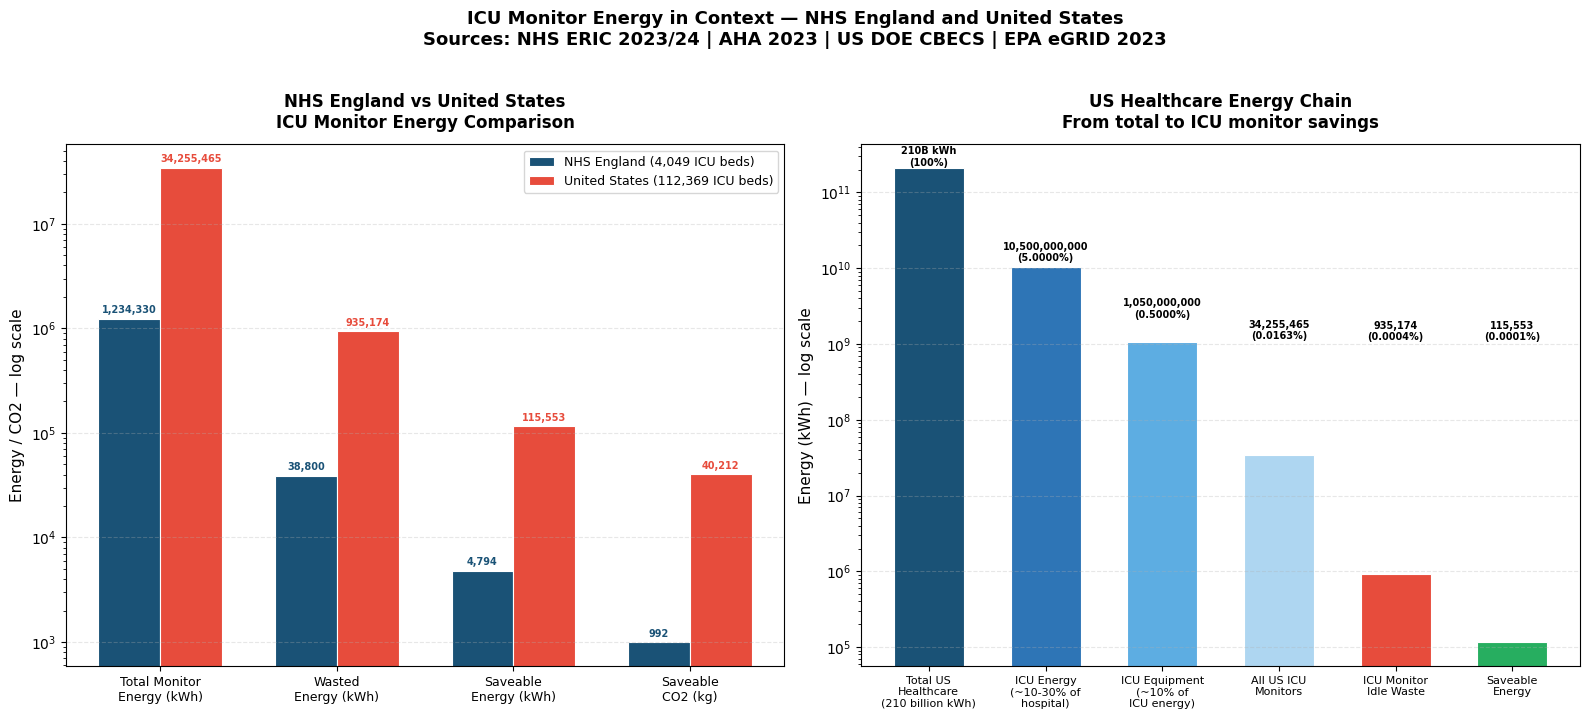

NHS vs US scaling chart saved to Desktop!


In [6]:
# I will create two visualisations for the NHS vs US scaling analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1 — NHS vs US Side by Side Comparison ──────────────

categories = ['Total Monitor\nEnergy (kWh)', 
              'Wasted\nEnergy (kWh)', 
              'Saveable\nEnergy (kWh)',
              'Saveable\nCO2 (kg)']

nhs_values = [1_234_330, 38_800, 4_794, 992]
us_values  = [34_255_465, 935_174, 115_553, 40_212]

x = range(len(categories))
width = 0.35

bars_nhs = axes[0].bar(
    [i - width/2 for i in x],
    nhs_values,
    width=width,
    color='#1A5276',
    edgecolor='white',
    linewidth=0.8,
    label='NHS England (4,049 ICU beds)'
)

bars_us = axes[0].bar(
    [i + width/2 for i in x],
    us_values,
    width=width,
    color='#E74C3C',
    edgecolor='white',
    linewidth=0.8,
    label='United States (112,369 ICU beds)'
)

# I will add value labels (multiplicative offset, so labels sit correctly on a log scale)
for bar in bars_nhs:
    val = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.08,
        f'{val:,.0f}',
        ha='center', va='bottom',
        fontsize=7, fontweight='bold',
        color='#1A5276'
    )

for bar in bars_us:
    val = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.08,
        f'{val:,.0f}',
        ha='center', va='bottom',
        fontsize=7, fontweight='bold',
        color='#E74C3C'
    )

axes[0].set_title(
    'NHS England vs United States\nICU Monitor Energy Comparison',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, fontsize=9)
axes[0].set_ylabel('Energy / CO2', fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].legend(fontsize=9)
axes[0].set_yscale('log')
axes[0].set_ylabel('Energy / CO2 — log scale', fontsize=11)

# ── Chart 2 — US Energy Chain Breakdown ──────────────────────

chain_labels = [
    'Total US\nHealthcare\n(210 billion kWh)',
    'ICU Energy\n(~10-30% of\nhospital)',
    'ICU Equipment\n(~10% of\nICU energy)',
    'All US ICU\nMonitors',
    'ICU Monitor\nIdle Waste',
    'Saveable\nEnergy'
]

# I will use approximate proportional values for visualisation
# Note — ICU and ICU equipment are estimates from literature
chain_values = [
    210_000_000_000,
    210_000_000_000 * 0.05,   # ~5% est hospital share of healthcare
    210_000_000_000 * 0.005,  # ~10% of ICU energy
    34_255_465,
    935_174,
    115_553
]

chain_colors = [
    '#1A5276',
    '#2E75B6',
    '#5DADE2',
    '#AED6F1',
    '#E74C3C',
    '#27AE60'
]

bars_chain = axes[1].bar(
    range(len(chain_labels)),
    chain_values,
    color=chain_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

# I will add percentage labels
for i, (bar, val) in enumerate(zip(bars_chain, chain_values)):
    if i > 0:
        pct = val / chain_values[0] * 100
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + chain_values[0] * 0.005,
            f'{val:,.0f}\n({pct:.4f}%)',
            ha='center', va='bottom',
            fontsize=7, fontweight='bold'
        )
    else:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + chain_values[0] * 0.005,
            f'{val/1e9:.0f}B kWh\n(100%)',
            ha='center', va='bottom',
            fontsize=7, fontweight='bold'
        )

axes[1].set_title(
    'US Healthcare Energy Chain\nFrom total to ICU monitor savings',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_xticks(range(len(chain_labels)))
axes[1].set_xticklabels(chain_labels, fontsize=8, ha='center')
axes[1].set_ylabel('Energy (kWh)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_ylabel('Energy (kWh) — log scale', fontsize=11)

fig.suptitle(
    'ICU Monitor Energy in Context — NHS England and United States\n'
    'Sources: NHS ERIC 2023/24 | AHA 2023 | US DOE CBECS | EPA eGRID 2023',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_nhs_us_scaling.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("NHS vs US scaling chart saved to Desktop!")

## Visualisation: NHS vs US Scaling Comparison

The left chart shows the direct comparison between NHS England 
(4,049 ICU beds) and the United States (112,369 ICU beds) across 
four metrics, total monitor energy, wasted energy, saveable energy 
and saveable CO2. The US figures are approximately 24-28x larger 
than NHS figures, consistent with the difference in ICU bed count.

The right chart shows the US healthcare energy chain on a log scale 
from 210 billion kWh total US healthcare energy down through ICU 
energy, ICU equipment energy, all US ICU monitors, idle waste, and 
finally saveable energy. The log scale is necessary because the values 
span six orders of magnitude. Patient monitor savings represent 
0.0001% of total US healthcare energy, a small but real and 
measurable contribution to healthcare sustainability.

## Analysis 4: Correlation Between Length of Stay and Idle Rate

I will test whether there is a statistically significant relationship 
between a patient's length of stay and their monitor idle percentage.

My hypothesis is that longer stays will show lower idle rates, 
patients who stay longer tend to be more critically ill and require 
more continuous monitoring. Shorter stays may be more variable, 
some will be high idle step-down patients, others will be actively 
monitored post-surgical patients.

I will run this analysis on both MIMIC-IV and eICU and report:
- Pearson correlation coefficient (r)
- P-value: to test statistical significance
- A scatter plot with regression line
- Interpretation of the finding

=== MIMIC-IV Correlation ===
Pearson r:    -0.1139
P-value:      0.000000
Slope:        -0.0105 (idle % change per hour of LOS)
Intercept:    6.0853
Significant:  Yes (p < 0.05)

=== eICU Correlation ===
Pearson r:    -0.0987
P-value:      0.000000
Slope:        -0.0218 (idle % change per hour of LOS)
Intercept:    7.5267
Significant:  Yes (p < 0.05)



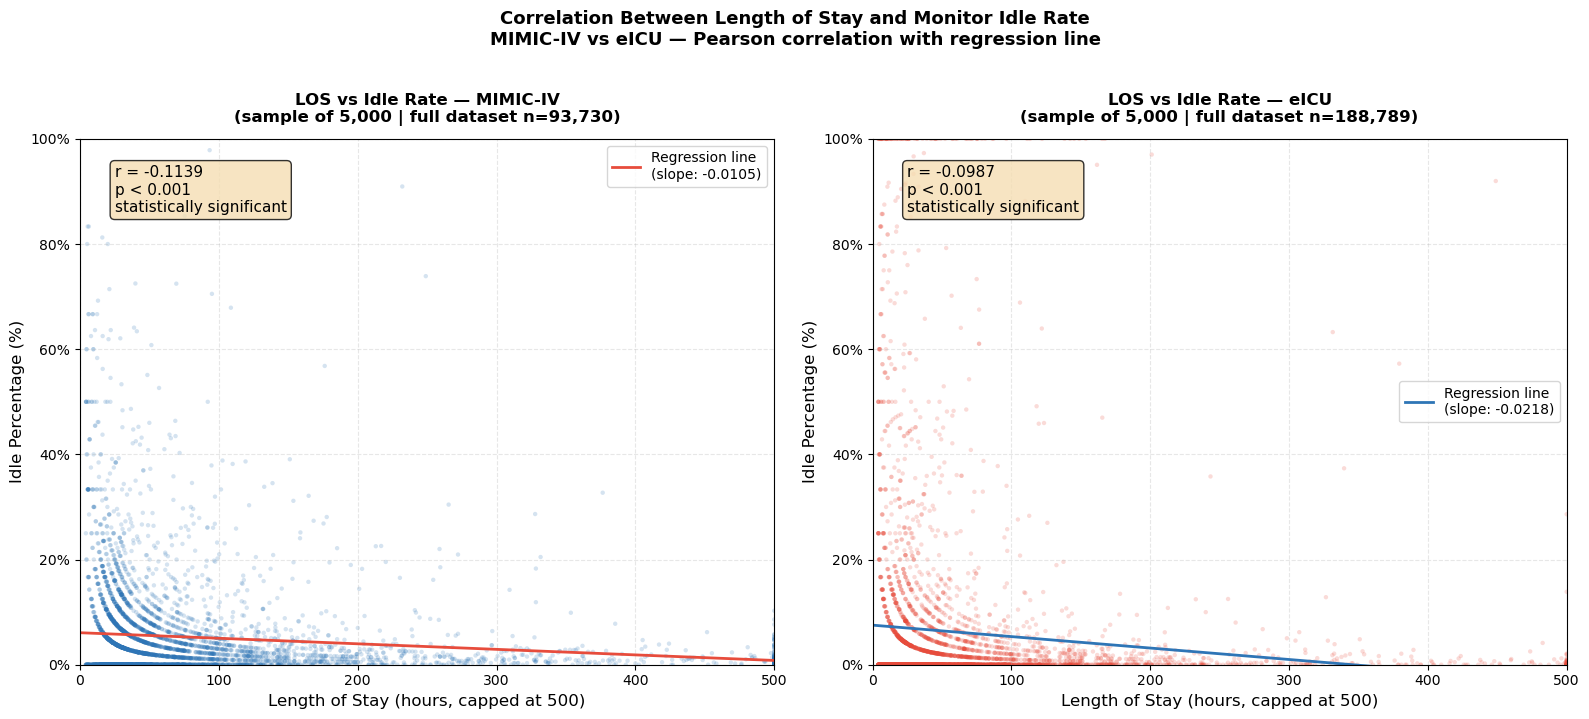

Correlation chart saved to Desktop!


In [ ]:
# I will test the correlation between length of stay and idle rate
# on both MIMIC-IV and eICU

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# I will use a sample of 5000 stays per dataset for plotting clarity
sample_mimic = stay_summary.sample(n=5000, random_state=42)
sample_eicu = stay_summary_eicu.sample(n=5000, random_state=42)

datasets = [
    (sample_mimic, stay_summary, 'MIMIC-IV', '#2E75B6', CO2_MIMIC, axes[0]),
    (sample_eicu, stay_summary_eicu, 'eICU', '#E74C3C', CO2_EICU, axes[1])
]

for sample, full_data, name, color, co2, ax in datasets:

    # I will calculate Pearson correlation on full dataset
    r, p_value = stats.pearsonr(
        full_data['los_hours'].clip(upper=500),
        full_data['idle_pct']
    )

    # I will plot scatter
    ax.scatter(
        sample['los_hours'].clip(upper=500),
        sample['idle_pct'],
        alpha=0.2,
        s=10,
        color=color,
        edgecolors='none'
    )

    # I will add regression line
    x_range = np.linspace(0, 500, 100)
    slope, intercept, _, _, _ = stats.linregress(
        full_data['los_hours'].clip(upper=500),
        full_data['idle_pct']
    )
    ax.plot(
        x_range,
        slope * x_range + intercept,
        color='#E74C3C' if name == 'MIMIC-IV' else '#2E75B6',
        linewidth=2,
        label=f'Regression line\n(slope: {slope:.4f})'
    )

    # I will add correlation stats
    p_text = f'p < 0.001' if p_value < 0.001 else f'p = {p_value:.3f}'
    significance = 'statistically significant' if p_value < 0.05 else 'not significant'

    ax.text(
        0.05, 0.95,
        f'r = {r:.4f}\n{p_text}\n{significance}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )

    ax.set_xlabel('Length of Stay (hours, capped at 500)', fontsize=12)
    ax.set_ylabel('Idle Percentage (%)', fontsize=12)
    ax.set_title(
        f'LOS vs Idle Rate — {name}\n'
        f'(sample of 5,000 | full dataset n={len(full_data):,})',
        fontsize=12, fontweight='bold', pad=12
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=10)

    print(f"=== {name} Correlation ===")
    print(f"Pearson r:    {r:.4f}")
    print(f"P-value:      {p_value:.6f}")
    print(f"Slope:        {slope:.4f} (idle % change per hour of LOS)")
    print(f"Intercept:    {intercept:.4f}")
    print(f"Significant:  {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")
    print()

fig.suptitle(
    'Correlation Between Length of Stay and Monitor Idle Rate\n'
    'MIMIC-IV vs eICU — Pearson correlation with regression line',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_correlation_los_idle.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Correlation chart saved to Desktop!")

## Correlation Analysis Results

### MIMIC-IV
- Pearson r = -0.1139 :weak negative correlation
- p < 0.001 : statistically significant
- Slope = -0.0105 idle % per hour of LOS

### eICU
- Pearson r = -0.0987 :weak negative correlation
- p < 0.001 :statistically significant
- Slope = -0.0218 idle % per hour of LOS

### Interpretation
The negative correlation confirms my hypothesis, longer ICU stays 
are associated with lower idle rates in both datasets. This is 
consistent with the clinical expectation that longer-staying patients 
tend to be more critically ill and require more continuous monitoring.

However the relationship is weak in both datasets (r ≈ -0.10). 
Length of stay alone explains only approximately 1% of the variation 
in idle rate (r² ≈ 0.01). The remaining 99% of variation is driven 
by other factors, primarily ICU unit type as demonstrated by my 
K-means clustering analysis, where the High Idle cluster was 
dominated by Neuro step-down patients regardless of their length 
of stay.

The cross-dataset consistency of this finding, the same direction 
and similar magnitude in both MIMIC-IV and eICU, provides further 
validation that this is a genuine pattern in ICU monitoring behaviour 
rather than a dataset-specific artefact.

### Clinical Implication
Since LOS alone is a poor predictor of idle rate, a purely LOS-based 
rule for activating low-power mode would be ineffective. This 
reinforces the argument for using K-means cluster membership, 
which captures unit type, idle pattern, and LOS together, as the 
basis for targeting AI-driven power optimisation.

## Analysis 5: Simulation Threshold Justification

I will document the literature sources that justify my three simulation 
scenario thresholds. This addresses the feedback from my supervisor 
Timo who correctly pointed out that the thresholds need either a 
literature source or a clearly stated clinical hypothesis.

I will use both, literature sources where available, and clinical 
reasoning where the literature provides context rather than exact 
figures.

### Conservative Scenario: 2 Hour Idle Threshold

Clinical justification:
Step-down unit vital signs are checked every 1-2 hours as standard 
practice. A 2-hour idle period therefore represents the maximum 
safe interval before the next check is due. Switching to low-power 
mode after 2 hours of no vital sign recordings is consistent with 
the standard nursing documentation interval for stable step-down 
patients.

Literature sources:
- "Vital signs are checked more frequently than on general floors, 
  often every one to two hours" in step-down units
  Source: Critical Care Explained — What Is a Step Down Unit
  https://snuggymom.com/what-is-a-step-down-unit-in-a-hospital/

- Definitive Step-Down Unit (DSU) protocol states vital signs are 
  taken every 1 hour then every 2-4 hours as indicated by patient 
  condition
  Source: California Department of Public Health DSU Protocol
  https://www.cdph.ca.gov/Programs/CHCQ/LCP/CalHealthFind/
  _vti_bin/HFCISService.svc/DownloadProgFlexDocByID?param=34180

### Moderate Scenario: 1 Hour Idle Threshold

Clinical justification:
For stable low-urgency patients nurses consider a 1-3 hour interval 
appropriate for the next vital sign observation. A 1-hour threshold 
captures the lower bound of what trained nurses consider safe for 
stable patients, more aggressive than the conservative scenario 
but still clinically defensible.

Literature source:
- A prospective study on nurse observation intervals found that in 
  low-urgency scenarios ALS-trained nurses selected intervals of 
  approximately 1 hour (median 1 hour vs 3 hours for less 
  experienced nurses)
  Source: PMC12736265 — Setting the Next Vital Sign Observation 
  Interval as a Learning Objective in Simulation-Based Nursing 
  Education
  https://www.ncbi.nlm.nih.gov/pmc/articles/PMC12736265/

### Aggressive Scenario: Immediate Low-Power Activation

Clinical justification:
For stable step-down patients the standard vital sign check interval 
can extend to 4 hours. Immediate low-power mode activation upon 
detecting an idle period is clinically defensible for the High Idle 
cluster specifically, these are predominantly Neuro step-down 
patients with stable vitals where the next nursing check may be 
several hours away.

Literature source:
- On step-down and telemetry units vital signs are typically checked 
  every 4 hours but could require more frequent checks based on 
  patient condition
  Source: HealthTasks — How Often Should You Check Vital Signs
  https://blog.healthtasks.ai/how-often-should-you-check-vital-signs/

### Why I Apply Different Scenarios to Different Clusters

The clinical feasibility of each scenario varies by patient cluster:

- Long Stay Critical: Conservative only (2 hour threshold)
  These patients have the highest clinical risk and most complex 
  conditions. Sudden deterioration is most likely in this group 
  and any automated power reduction must be cautious.

- Standard ICU: Conservative and Moderate (2 and 1 hour thresholds)
  Moderate clinical risk with some possibility of deterioration. 
  The aggressive scenario is not applied since these patients are 
  not as stable as step-down patients.

- High Idle: All three scenarios including Aggressive
  Predominantly Neuro Intermediate and Neuro Stepdown patients 
  with stable vitals and infrequent monitoring. This is the only 
  cluster where immediate low-power activation is clinically 
  defensible based on the literature above.

This cluster-specific approach was recommended by my supervisor 
Timo and will form a key part of the discussion section of my 
thesis connecting simulation findings to real-world clinical 
constraints.

In [ ]:
from scipy import stats

# Kruskal-Wallis test: does idle_pct differ significantly across hospital size categories?
groups = [
    stay_summary_eicu[stay_summary_eicu['numbedscategory'] == cat]['idle_pct'].dropna()
    for cat in ['<100', '100 - 249', '250 - 499', '>= 500']
]

h_stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p = {p_value:.4f}")

Kruskal-Wallis H = 166.88, p = 0.0000
